In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/kkbox-music-recommendation-challenge/test.csv.7z
/kaggle/input/kkbox-music-recommendation-challenge/train.csv.7z
/kaggle/input/kkbox-music-recommendation-challenge/songs.csv.7z
/kaggle/input/kkbox-music-recommendation-challenge/members.csv.7z
/kaggle/input/kkbox-music-recommendation-challenge/song_extra_info.csv.7z
/kaggle/input/kkbox-music-recommendation-challenge/sample_submission.csv.7z


In [2]:
# From https://www.kaggle.com/code/pahirathannithilan/music-recommendation-system-letsgrowmore
def reduce_mem_usage(df):
    """ iterate through all the columns of a dataframe and modify the data type
        to reduce memory usage.        
    """
    start_mem = df.memory_usage().sum() / 1024**2
    print('Memory usage of dataframe is {:.2f} MB'.format(start_mem))
    
    for col in df.columns:
        col_type = df[col].dtype
        
        if col_type != object:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)  
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)
        else:
            df[col] = df[col].astype('category')

    end_mem = df.memory_usage().sum() / 1024**2
    print('Memory usage after optimization is: {:.2f} MB'.format(end_mem))
    print('Decreased by {:.1f}%'.format(100 * (start_mem - end_mem) / start_mem))
    
    return df

In [3]:
!pip install datatable
!pip install pyunpack patool

os.system('apt-get install p7zip')
import os , sys
from pyunpack.cli import Archive

import datatable as dt

directory = '/kaggle/working/'
Archive('/kaggle/input/kkbox-music-recommendation-challenge/train.csv.7z').extractall(directory)
Archive('/kaggle/input/kkbox-music-recommendation-challenge/test.csv.7z').extractall(directory)
Archive('/kaggle/input/kkbox-music-recommendation-challenge/songs.csv.7z').extractall(directory)
Archive('/kaggle/input/kkbox-music-recommendation-challenge/members.csv.7z').extractall(directory)
Archive('/kaggle/input/kkbox-music-recommendation-challenge/song_extra_info.csv.7z').extractall(directory)

#sys.exit("Error message")
train_df = reduce_mem_usage(dt.fread('./train.csv').to_pandas())
test_df = reduce_mem_usage(dt.fread('./test.csv').to_pandas())
songs_df = reduce_mem_usage(dt.fread('./songs.csv').to_pandas()) #'composer', 'lyricist'
members_df = reduce_mem_usage(dt.fread('./members.csv').to_pandas())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.0/82.0 MB 20.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.3/86.3 kB 2.5 MB/s eta 0:00:00
Reading package lists...
Building dependency tree...
Reading state information...
p7zip is already the newest version (16.02+dfsg-8).
p7zip set to manually installed.
0 upgraded, 0 newly installed, 0 to remove and 122 not upgraded.


Memory usage of dataframe is 288.46 MB
Memory usage after optimization is: 89.45 MB
Decreased by 69.0%
Memory usage of dataframe is 107.29 MB
Memory usage after optimization is: 42.17 MB
Decreased by 60.7%
Memory usage of dataframe is 113.88 MB
Memory usage after optimization is: 159.83 MB
Decreased by -40.4%
Memory usage of dataframe is 1.18 MB
Memory usage after optimization is: 1.83 MB
Decreased by -54.8%


In [4]:
# EDA

In [5]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7377418 entries, 0 to 7377417
Data columns (total 6 columns):
 #   Column              Dtype   
---  ------              -----   
 0   msno                category
 1   song_id             category
 2   source_system_tab   category
 3   source_screen_name  category
 4   source_type         category
 5   target              float16 
dtypes: category(5), float16(1)
memory usage: 89.4 MB


In [6]:
members_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34403 entries, 0 to 34402
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   msno                    34403 non-null  category
 1   city                    34403 non-null  int8    
 2   bd                      34403 non-null  int16   
 3   gender                  34403 non-null  category
 4   registered_via          34403 non-null  int8    
 5   registration_init_time  34403 non-null  int32   
 6   expiration_date         34403 non-null  int32   
dtypes: category(2), int16(1), int32(2), int8(2)
memory usage: 1.8 MB


In [7]:
songs_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2296320 entries, 0 to 2296319
Data columns (total 7 columns):
 #   Column       Dtype   
---  ------       -----   
 0   song_id      category
 1   song_length  int32   
 2   genre_ids    category
 3   artist_name  category
 4   composer     category
 5   lyricist     category
 6   language     float16 
dtypes: category(5), float16(1), int32(1)
memory usage: 159.8 MB


In [8]:
train_df.isnull().sum()

msno                  0
song_id               0
source_system_tab     0
source_screen_name    0
source_type           0
target                0
dtype: int64

In [9]:
test_df.isnull().sum()

id                    0
msno                  0
song_id               0
source_system_tab     0
source_screen_name    0
source_type           0
dtype: int64

In [10]:
songs_df.isnull().sum()

song_id        0
song_length    0
genre_ids      0
artist_name    0
composer       0
lyricist       0
language       1
dtype: int64

In [11]:
members_df.isnull().sum()

msno                      0
city                      0
bd                        0
gender                    0
registered_via            0
registration_init_time    0
expiration_date           0
dtype: int64

In [12]:
combined_train_df = train_df.merge(members_df, on='msno', how='left')
combined_train_df = combined_train_df.merge(songs_df, on='song_id', how='left')

In [13]:
combined_test_df = test_df.merge(members_df, on='msno', how='left')
combined_test_df = combined_test_df.merge(songs_df, on='song_id', how='left')

In [14]:
combined_train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7377418 entries, 0 to 7377417
Data columns (total 18 columns):
 #   Column                  Dtype   
---  ------                  -----   
 0   msno                    object  
 1   song_id                 object  
 2   source_system_tab       category
 3   source_screen_name      category
 4   source_type             category
 5   target                  float16 
 6   city                    int8    
 7   bd                      int16   
 8   gender                  category
 9   registered_via          int8    
 10  registration_init_time  int32   
 11  expiration_date         int32   
 12  song_length             float64 
 13  genre_ids               category
 14  artist_name             category
 15  composer                category
 16  lyricist                category
 17  language                float16 
dtypes: category(8), float16(2), float64(1), int16(1), int32(2), int8(2), object(2)
memory usage: 433.3+ MB


In [15]:
numerical_types = ['int8', 'int16', 'int32', 'int64', 'float16', 'float32', 'float64']
numerical_cols = [col for col in combined_train_df.columns if str(combined_train_df[col].dtype) in numerical_types]

# Categorical types
categorical_cols = [col for col in combined_train_df.columns if str(combined_train_df[col].dtype) == 'category']

# Object (usually string) types
object_cols = [col for col in combined_train_df.columns if str(combined_train_df[col].dtype) == 'object']

print("Numerical columns:", numerical_cols)
print("Categorical columns:", categorical_cols)
print("Object columns:", object_cols)

Numerical columns: ['target', 'city', 'bd', 'registered_via', 'registration_init_time', 'expiration_date', 'song_length', 'language']
Categorical columns: ['source_system_tab', 'source_screen_name', 'source_type', 'gender', 'genre_ids', 'artist_name', 'composer', 'lyricist']
Object columns: ['msno', 'song_id']


In [16]:
columns_cat_with_int = ['city', 'bd', 'registered_via', 'registration_init_time', 'expiration_date', 'language']

# Remove these from numerical_cols if they exist
numerical_cols = [col for col in numerical_cols if col not in columns_cat_with_int]

# Add them to categorical_cols (avoiding duplicates)
categorical_cols = list(set(categorical_cols + columns_cat_with_int))

target = 'target'


In [17]:
print("Numerical columns:", numerical_cols)
print("Categorical columns:", categorical_cols)
print("Object columns:", object_cols)

Numerical columns: ['target', 'song_length']
Categorical columns: ['composer', 'bd', 'expiration_date', 'language', 'city', 'genre_ids', 'source_system_tab', 'lyricist', 'registered_via', 'source_type', 'gender', 'source_screen_name', 'artist_name', 'registration_init_time']
Object columns: ['msno', 'song_id']


In [18]:
numerical_cols.remove(target)

In [19]:
combined_train_df[target] = combined_train_df[target].astype(int).astype('category')

In [20]:
import matplotlib.pyplot as plt

In [21]:
categorical_cols

['composer',
 'bd',
 'expiration_date',
 'language',
 'city',
 'genre_ids',
 'source_system_tab',
 'lyricist',
 'registered_via',
 'source_type',
 'gender',
 'source_screen_name',
 'artist_name',
 'registration_init_time']

In [22]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

### Plotting feature relation with target

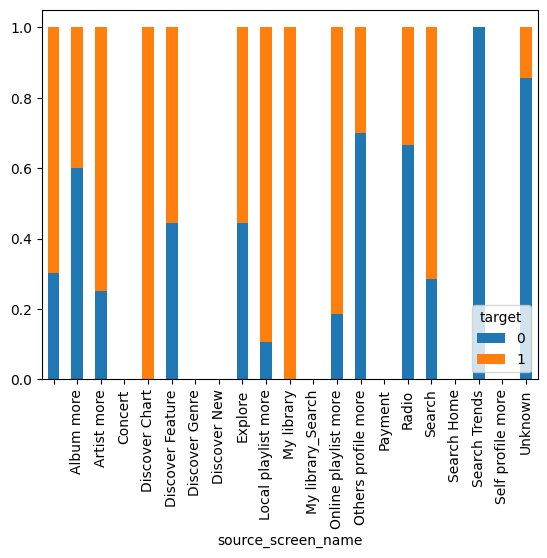

In [23]:
grouped = combined_train_df.head(1000).groupby(['source_screen_name', target],observed=False).size().unstack(fill_value=0)
grouped_percentage = grouped.div(grouped.sum(axis=1),axis=0).plot(kind='bar',stacked=True)
plt.show()

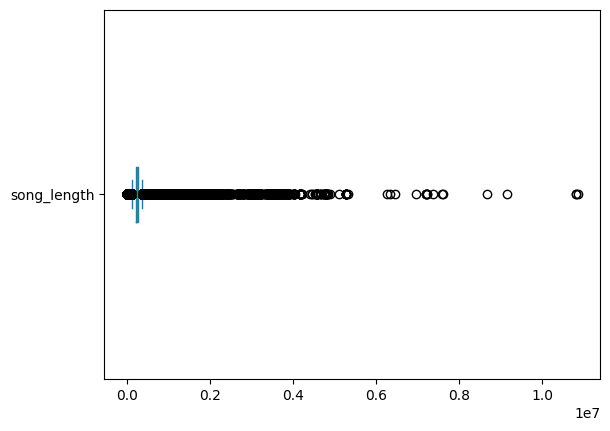

In [24]:
for col in numerical_cols:
    selected = combined_train_df[[col, target]].plot(kind='box',vert=False)
    plt.show()

## Check feature correlations

In [25]:
import pandas as pd
import numpy as np
from scipy import stats
from typing import Union, Tuple

def numerical_correlation(df: pd.DataFrame, col1: str, col2: str) -> Tuple[float, str]:
    """
    Calculate correlation between two numerical columns.
    
    Args:
        df (pd.DataFrame): Input DataFrame
        col1 (str): Name of first numerical column
        col2 (str): Name of second numerical column
    
    Returns:
        Tuple[float, str]: Correlation coefficient and method used
    """
    # Check if columns exist
    if col1 not in df.columns or col2 not in df.columns:
        raise ValueError("One or both column names not found in DataFrame")
    
    # Check if columns are numerical
    if not pd.api.types.is_numeric_dtype(df[col1]) or not pd.api.types.is_numeric_dtype(df[col2]):
        raise ValueError("Both columns must be numerical")
    
    # Calculate Pearson correlation
    correlation = df[col1].corr(df[col2], method='pearson')
    return correlation, 'pearson'

def numerical_categorical_correlation(df: pd.DataFrame, numerical_col: str, categorical_col: str) -> Tuple[float, str]:
    """
    Calculate correlation between a numerical and categorical column.
    
    Args:
        df (pd.DataFrame): Input DataFrame
        numerical_col (str): Name of numerical column
        categorical_col (str): Name of categorical column
    
    Returns:
        Tuple[float, str]: Correlation coefficient and method used
    """
    # Check if columns exist
    if numerical_col not in df.columns or categorical_col not in df.columns:
        raise ValueError("One or both column names not found in DataFrame")
    
    # Check if columns are of correct types
    if not pd.api.types.is_numeric_dtype(df[numerical_col]):
        raise ValueError(f"{numerical_col} must be numerical")
    
    # Get unique categories
    n_categories = df[categorical_col].nunique()
    
    if n_categories == 2:
        # For binary categorical variables, use point-biserial correlation
        # Convert categorical to numeric (0, 1)
        categorical_numeric = pd.Categorical(df[categorical_col]).codes
        correlation, _ = stats.pointbiserialr(categorical_numeric, df[numerical_col])
        method = 'point-biserial'
    else:
        # For multi-class categorical variables, use correlation ratio (eta)
        categories = df[categorical_col].unique()
        grand_mean = df[numerical_col].mean()
        n_total = len(df)
        
        # Calculate correlation ratio (η)
        ss_total = ((df[numerical_col] - grand_mean) ** 2).sum()
        ss_between = sum(len(df[df[categorical_col] == cat]) * 
                        (df[df[categorical_col] == cat][numerical_col].mean() - grand_mean) ** 2 
                        for cat in categories)
        
        correlation = np.sqrt(ss_between / ss_total)
        method = 'correlation-ratio'
    
    return correlation, method

def categorical_correlation(df: pd.DataFrame, col1: str, col2: str) -> Tuple[float, str]:
    """
    Calculate correlation between two categorical columns using Cramer's V.
    
    Args:
        df (pd.DataFrame): Input DataFrame
        col1 (str): Name of first categorical column
        col2 (str): Name of second categorical column
    
    Returns:
        Tuple[float, str]: Correlation coefficient and method used
    """
    # Check if columns exist
    if col1 not in df.columns or col2 not in df.columns:
        raise ValueError("One or both column names not found in DataFrame")
    
    # Create contingency table
    contingency = pd.crosstab(df[col1], df[col2])
    
    # Calculate Chi-square statistic and Cramer's V
    chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
    n = len(df)
    min_dim = min(contingency.shape) - 1
    
    # Calculate Cramer's V
    cramer_v = np.sqrt(chi2 / (n * min_dim))
    
    return cramer_v, 'cramer_v'

def get_correlation(df: pd.DataFrame, col1: str, col2: str) -> Tuple[float, str]:
    """
    Automatically determine and calculate the appropriate correlation between two columns.
    
    Args:
        df (pd.DataFrame): Input DataFrame
        col1 (str): Name of first column
        col2 (str): Name of second column
    
    Returns:
        Tuple[float, str]: Correlation coefficient and method used
    """
    # Check if columns are numerical
    is_num1 = pd.api.types.is_numeric_dtype(df[col1])
    is_num2 = pd.api.types.is_numeric_dtype(df[col2])
    
    if is_num1 and is_num2:
        return numerical_correlation(df, col1, col2)
    elif is_num1 and not is_num2:
        return numerical_categorical_correlation(df, col1, col2)
    elif not is_num1 and is_num2:
        return numerical_categorical_correlation(df, col2, col1)
    else:
        return categorical_correlation(df, col1, col2)


In [26]:
columns = combined_train_df.columns.to_list()

In [27]:
for col in columns:
    res = get_correlation(combined_train_df, col, 'target')
    print(f"The {res[1]} between {col} and target is {res[0]}")

The cramer_v between msno and target is 0.37502220886819015
The cramer_v between song_id and target is 0.31876023086076033
The cramer_v between source_system_tab and target is 0.25102731208244505
The cramer_v between source_screen_name and target is 0.2683590859855311
The cramer_v between source_type and target is 0.2693056450345676
The cramer_v between target and target is 0.999999728889028
The point-biserial between city and target is 0.012114385662670752
The point-biserial between bd and target is -0.0005003128269233601
The cramer_v between gender and target is 0.01906937956604409
The point-biserial between registered_via and target is 0.00989281223848852
The point-biserial between registration_init_time and target is -0.0020323125530043594
The point-biserial between expiration_date and target is 0.044250177506157465


/usr/local/lib/python3.11/dist-packages/scipy/stats/_stats_py.py:4638: RuntimeWarning: invalid value encountered in less
  nconst_y = xp.any(normym < threshold*xp.abs(ymean), axis=axis)
/usr/local/lib/python3.11/dist-packages/scipy/_lib/array_api_compat/common/_aliases.py:354: RuntimeWarning: invalid value encountered in less
  ia = (out < a) | xp.isnan(a)
/usr/local/lib/python3.11/dist-packages/scipy/_lib/array_api_compat/common/_aliases.py:361: RuntimeWarning: invalid value encountered in greater
  ib = (out > b) | xp.isnan(b)


The point-biserial between song_length and target is nan
The cramer_v between genre_ids and target is 0.08697256710816792
The cramer_v between artist_name and target is 0.20312057482149168
The cramer_v between composer and target is 0.21054475253071425
The cramer_v between lyricist and target is 0.17060843700289166


/usr/local/lib/python3.11/dist-packages/numpy/core/_methods.py:118: RuntimeWarning: invalid value encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/usr/local/lib/python3.11/dist-packages/scipy/stats/_stats_py.py:4624: RuntimeWarning: invalid value encountered in subtract
  ym = y - ymean
/usr/local/lib/python3.11/dist-packages/numpy/linalg/linalg.py:2583: RuntimeWarning: overflow encountered in reduce
  return sqrt(add.reduce(s, axis=axis, keepdims=keepdims))


The point-biserial between language and target is nan


### Discover loading errors of song info

In [28]:
!wc -l songs.csv  

2296834 songs.csv


In [29]:
print(songs_df.shape)

(2296320, 7)


In [30]:
missing_ids = set(train_df['song_id']) - set(songs_df['song_id'])
len(missing_ids)

52

In [31]:
combined_train_df.head()

,msno,song_id,source_system_tab,source_screen_name,source_type,target,city,bd,gender,registered_via,registration_init_time,expiration_date,song_length,genre_ids,artist_name,composer,lyricist,language
0,FGtllVqz18RPiwJj/edr2gV78zirAiY/9SmYvia+kCg=,BBzumQNXUHKdEBOB7mAJuzok+IJA1c2Ryg/yzTF6tik=,explore,Explore,online-playlist,1,1,0,,7,20120102,20171005,206471.0,359,Bastille,Dan Smith| Mark Crew,,52.0
1,Xumu+NIjS6QYVxDS4/t3SawvJ7viT9hPKXmf0RtLNx8=,bhp/MpSNoqoxOIB+/l8WPqu6jldth4DIpCm3ayXnJqM=,my library,Local playlist more,local-playlist,1,13,24,female,9,20110525,20170911,284584.0,1259,Various Artists,,,52.0
2,Xumu+NIjS6QYVxDS4/t3SawvJ7viT9hPKXmf0RtLNx8=,JNWfrrC7zNN7BdMpsISKa4Mw+xVJYNnxXh3/Epw7QgY=,my library,Local playlist more,local-playlist,1,13,24,female,9,20110525,20170911,225396.0,1259,Nas,N. Jones、W. Adams、J. Lordan、D. Ingle,,52.0
3,Xumu+NIjS6QYVxDS4/t3SawvJ7viT9hPKXmf0RtLNx8=,2A87tzfnJTSWqD7gIZHisolhe4DMdzkbd6LzO1KHjNs=,my library,Local playlist more,local-playlist,1,13,24,female,9,20110525,20170911,255512.0,1019,Soundway,Kwadwo Donkoh,,-1.0
4,FGtllVqz18RPiwJj/edr2gV78zirAiY/9SmYvia+kCg=,3qm6XTZ6MOCU11x8FIVbAGH5l5uMkT3/ZalWG1oo2Gc=,explore,Explore,online-playlist,1,1,0,,7,20120102,20171005,187802.0,1011,Brett Young,Brett Young| Kelly Archer| Justin Ebach,,52.0


# Feature Engineering

In [32]:
train_and_test = pd.concat((train_df.drop('target',axis =1), test_df)).reset_index(drop=True)
 

In [33]:
train_and_test = train_and_test.merge(members_df, on='msno', how='left')
train_and_test = train_and_test.merge(songs_df, on='song_id', how='left')

In [34]:
train_and_test['registration_init_time'] = pd.to_datetime(train_and_test['registration_init_time'], format='%Y%m%d')
train_and_test['expiration_date'] = pd.to_datetime(train_and_test['expiration_date'], format='%Y%m%d')


In [35]:
train_and_test['registration_init_year']=train_and_test['registration_init_time'].dt.year
train_and_test['registration_init_month']=train_and_test['registration_init_time'].dt.month
train_and_test['expiration_year']=train_and_test['expiration_date'].dt.year
train_and_test['expiration_month']=train_and_test['expiration_date'].dt.month

In [36]:
train_and_test.drop(['registration_init_time','expiration_date'] , axis = 1 , inplace= True)

In [37]:
train_and_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9934208 entries, 0 to 9934207
Data columns (total 20 columns):
 #   Column                   Dtype   
---  ------                   -----   
 0   msno                     object  
 1   song_id                  object  
 2   source_system_tab        category
 3   source_screen_name       object  
 4   source_type              category
 5   id                       float64 
 6   city                     int8    
 7   bd                       int16   
 8   gender                   category
 9   registered_via           int8    
 10  song_length              float64 
 11  genre_ids                category
 12  artist_name              category
 13  composer                 category
 14  lyricist                 category
 15  language                 float16 
 16  registration_init_year   int32   
 17  registration_init_month  int32   
 18  expiration_year          int32   
 19  expiration_month         int32   
dtypes: category(7), float16(

# Model Training And Evaluation

In [38]:
train_x = train_and_test[:train_df.shape[0]].drop(['msno','song_id','id'],axis=1)
train_x['source_screen_name'] = train_x['source_screen_name'].astype('category')
train_y = train_df['target'].astype(int)

In [39]:
import lightgbm as lgb
import time
params = {
        'objective': 'binary',
        'metric': 'binary_logloss',
        'verbose': 0,
        'num_rounds': 200,
        'metric' : 'auc'
    }

train_data = lgb.Dataset(train_x , train_y)
%time model = lgb.train(params, train_set=train_data,  valid_sets=train_data, callbacks=[lgb.log_evaluation(period=5)])


[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[5]	training's auc: 0.678769
[10]	training's auc: 0.682158
[15]	training's auc: 0.685034
[20]	training's auc: 0.687342
[25]	training's auc: 0.68956
[30]	training's auc: 0.691342
[35]	training's auc: 0.692984
[40]	training's auc: 0.694286
[45]	training's auc: 0.695638
[50]	training's auc: 0.696869
[55]	training's auc: 0.697882
[60]	training's auc: 0.698964
[65]	training's auc: 0.699889
[70]	training's auc: 0.700851
[75]	training's auc: 0.701606
[80]	training's auc: 0.702426
[85]	training's auc: 0.703181
[90]	training's auc: 0.703952
[95]	training's auc: 0.70481
[100]	training's auc: 0.705463
[105]	training's auc: 0.706096
[110]	training's auc: 0.706817
[115]	training's auc: 0.707417
[120]	training's auc: 0.70796
[125]	training's auc: 0.708593
[130]	training's 

In [40]:
!pip install shap
import shap

# Initialize the explainer with your trained model
explainer = shap.TreeExplainer(model)

# Choose an instance to explain (e.g., the first one)
instance = train_x.iloc[[0]]

# Calculate SHAP values
shap_values = explainer.shap_values(instance)

# Visualize the explanation
shap.initjs()
shap.force_plot(explainer.expected_value[1], shap_values[1], instance)


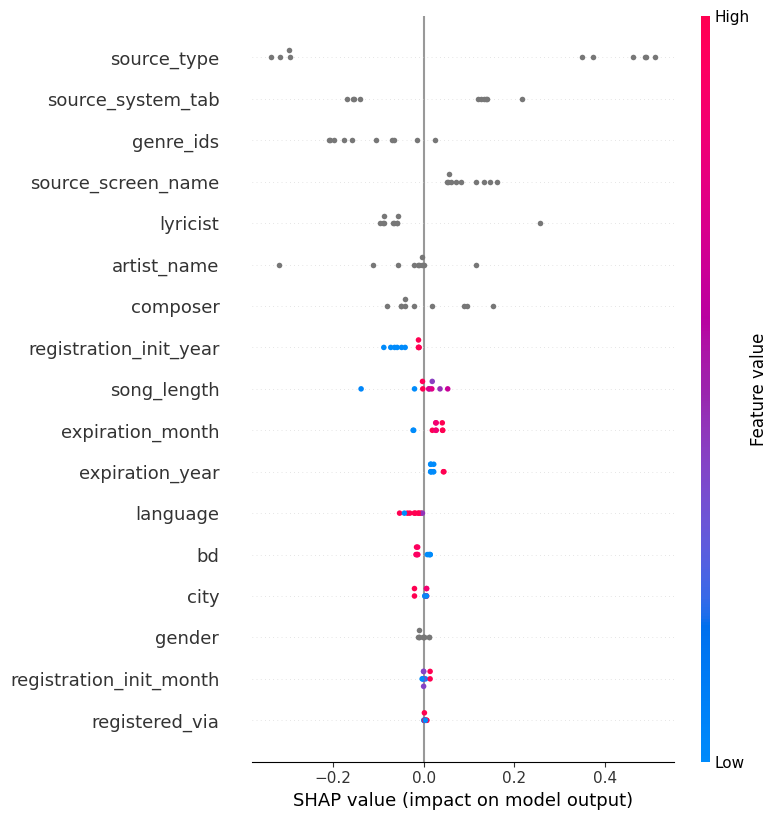

In [41]:
all_train_samples = train_x[:10]
shap_values_all = explainer.shap_values(all_train_samples)

# Summary plot of global feature importance
shap.summary_plot(shap_values_all[1], all_train_samples)

## Try Decision Tree for better interpretability

In [42]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
import pandas as pd

# Split columns by type
cat_cols = train_x.select_dtypes(include='category').columns.tolist()
num_cols = train_x.select_dtypes(exclude='category').columns.tolist()

# Preprocessing pipelines
cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean'))
])

# Full preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', cat_pipeline, cat_cols),
        ('num', num_pipeline, num_cols)
    ]
)

# Final pipeline
model2 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42, max_depth=5, min_samples_split=10, min_samples_leaf=5))
])


In [43]:

# Fit the model
model2.fit(train_x, train_y)


invalid value encountered in reduce
invalid value encountered in reduce


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['source_system_tab',
                                                   'source_screen_name',
                                                   'source_type', 'gender',
                                                   'genre_ids', 'artist_name',
                                                   'composer', 'lyricist']),
                                                 ('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer())]),
                                                  ['city', 'bd',
                                                   'registered_via',
                                                   'song_length', 'language',
                                                   'registration_init_year',
                                                   'registration_init_month',
                                                   'expiration_year',
                                                   'expiration_month'])])),
                ('classifier',
                 DecisionTreeClassifier(max_depth=5, min_samples_leaf=5,
                                        min_samples_split=10,
                                        random_state=42))])

In [44]:
tree_model = model2.named_steps['classifier']
ohe = model2.named_steps['preprocessor'].named_transformers_['cat'].named_steps['encoder']
feature_names = (
    list(ohe.get_feature_names_out(input_features=cat_cols)) +
    num_cols
)

In [45]:
from sklearn.tree import _tree
import numpy as np

def explain_decision_tree_sample(model, preprocessor, feature_names, sample):
    """
    Print the decision rules and prediction for one sample.
    
    Args:
        model: Trained sklearn DecisionTreeClassifier.
        preprocessor: Preprocessing pipeline from ColumnTransformer.
        feature_names: List of feature names after preprocessing.
        sample: A single-row DataFrame (raw, not preprocessed).
    """
    tree = model.tree_
    feature = tree.feature
    threshold = tree.threshold

    # Preprocess test sample
    sample = preprocessor.transform(sample)  # transform into numeric array
    
    node_indicator = model.decision_path(sample)
    leaf_id = model.apply(sample)[0]
    
    print(f"Decision path for sample 0:")
    for node_id in node_indicator.indices[node_indicator.indptr[0] : node_indicator.indptr[1]]:
        if node_id == leaf_id:
            print(f"--> Reached leaf node {node_id}")
            value = tree.value[node_id][0]
            class_prob = value / value.sum()
            predicted_class = model.classes_[np.argmax(class_prob)]
            print(f"    Class distribution at leaf: {value}")
            print(f"    Class probabilities: {class_prob}")
            print(f"    Predicted class: {predicted_class}")
            continue
        feat_name = feature_names[feature[node_id]]
        thresh = threshold[node_id]
        val = sample[0, feature[node_id]]
        decision = "<=" if val <= thresh else ">"
        print(f"Node {node_id}: ({feat_name} = {val:.3f}) {decision} {thresh:.3f}")


In [46]:
test_x = train_and_test[train_df.shape[0]:].drop(['msno','song_id','id'],axis=1)
test_x['source_screen_name'] = test_x['source_screen_name'].astype('category')

In [47]:
ohe = model2.named_steps['preprocessor']
explain_decision_tree_sample(tree_model, ohe, feature_names, test_x.iloc[0:1])

Decision path for sample 0:
Node 0: (source_screen_name_Local playlist more = 1.000) > 0.500
Node 32: (source_system_tab_my library = 1.000) > 0.500
Node 48: (expiration_year = 2017.000) > 2016.500
Node 56: (registration_init_year = 2016.000) > 2012.500
Node 60: (lyricist_ = 1.000) > 0.500
--> Reached leaf node 62
    Class distribution at leaf: [267733. 472870.]
    Class probabilities: [0.36150677 0.63849323]
    Predicted class: 1


In [48]:
test_pred = model.predict(test_x)

In [49]:
test_pred = (test_pred>0.5).astype(int)

In [50]:
sububssion = pd.DataFrame()
sububssion['id'] = test_df['id']
sububssion['target'] = test_pred
sububssion.to_csv('submission.csv',index=False)
sububssion.head()

,id,target
0,0,1
1,1,1
2,2,0
3,3,0
4,4,0
